In [1]:
import os
import tarfile
from six.moves import urllib
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

In [2]:
bay_area_path = os.path.join("data/bay_area_medispa_data.csv")
bay_area = pd.read_csv(bay_area_path)

seattle_area_path = os.path.join("data/seattle_area_medispa_data.csv")
seattle_area = pd.read_csv(seattle_area_path)

bay_spas = pd.read_csv('data/bay_area_medispas.csv')
seattle_spas = pd.read_csv('data/seattle_area_medispas.csv')

In [3]:
bay_area.head()

,ZIP Code,Latitude,Longitude,Population (Women 35-65),City,Area/Neighborhood,Spa Count,Market Opportunity Score,Opportunity Tier
0,95138,37.2462,-121.7794,7200,San Jose,Coyote Valley,0,7200,Tier 1 - Excellent
1,95051,37.3696,-121.9763,7200,Santa Clara,North Santa Clara,0,7200,Tier 1 - Excellent
2,95135,37.3018,-121.7542,6900,San Jose,Communications Hill,0,6900,Tier 1 - Excellent
3,95054,37.3910,-121.9629,6900,Santa Clara,Mission College,0,6900,Tier 1 - Excellent
4,94110,37.7486,-122.4171,6800,San Francisco,Mission,0,6800,Tier 1 - Excellent


In [4]:
seattle_area.head()

,ZIP Code,Latitude,Longitude,Population (Women 35-65),City,Area/Neighborhood,Spa Count,Market Opportunity Score,Opportunity Tier
0,98006,47.5650,-122.1484,6900,Bellevue,South Bellevue/Newcastle,0,6900.0,Tier 1 - Excellent
1,98115,47.6847,-122.3013,6800,Seattle,Lake City/Wedgwood,0,6800.0,Tier 1 - Excellent
2,98075,47.5761,-122.0335,6800,Sammamish,South Sammamish,0,6800.0,Tier 1 - Excellent
3,98023,47.3092,-122.3479,6800,Federal Way,West Federal Way,0,6800.0,Tier 1 - Excellent
4,98005,47.6178,-122.1861,6800,Bellevue,Eastgate/Somerset,0,6800.0,Tier 1 - Excellent


<Axes: xlabel='Longitude', ylabel='Latitude'>

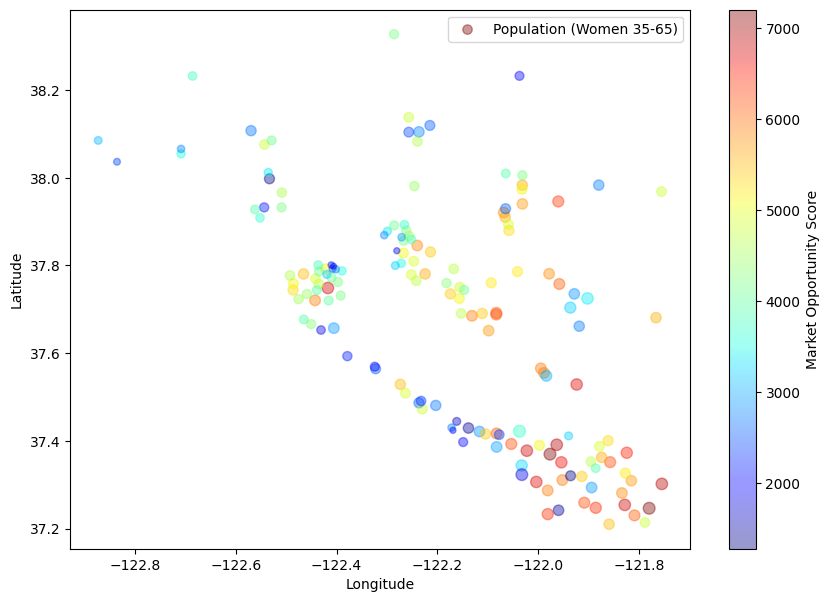

In [5]:
bay_area = bay_area.copy()
bay_area.plot(kind="scatter", x="Longitude",y="Latitude",alpha=0.4, s=bay_area["Population (Women 35-65)"]/100,label="Population (Women 35-65)",figsize=(10,7),
            c="Market Opportunity Score",cmap=plt.get_cmap("jet"), colorbar=True)

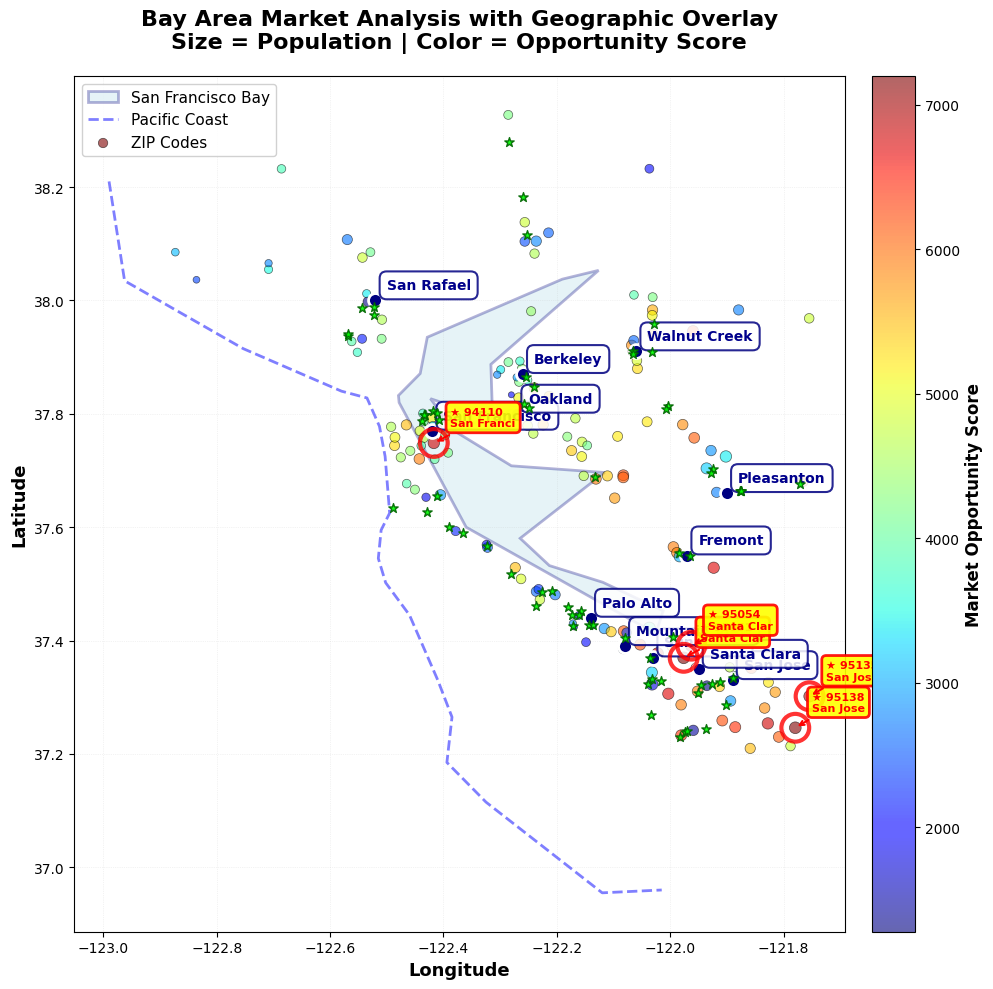

✅ Enhanced plot with Bay Area overlay and city labels saved!


In [19]:
"""
Enhanced Bay Area Plotting with Geographic Overlay
Add this code to overlay SF Bay map on your scatter plot
"""

# Define SF Bay geography
def create_bay_overlay(ax):
    """Add San Francisco Bay and coastline overlay to axis"""
    
    # San Francisco Bay polygon (simplified outline)
    sf_bay_coords_old = [
        (-122.50, 38.08), (-122.42, 38.02), (-122.35, 37.96),
        (-122.31, 37.90), (-122.28, 37.86), (-122.26, 37.80),
        (-122.22, 37.72), (-122.18, 37.64), (-122.10, 37.54),
        (-122.04, 37.46), (-122.02, 37.40), (-122.10, 37.38),
        (-122.20, 37.42), (-122.28, 37.48), (-122.35, 37.55),
        (-122.40, 37.64), (-122.44, 37.72), (-122.48, 37.82),
        (-122.50, 37.92), (-122.52, 38.00)
    ]

    sf_bay_coords = [
    (-122.4783, 37.8199), # Golden Gate Bridge (West entrance)
    (-122.4795, 37.8323), # Lime Point (North side of GG Bridge)
    (-122.4411, 37.8711), # Belvedere / Tiburon
    (-122.4286, 37.9351), # Richmond-San Rafael Bridge (North Bay)
    (-122.1903, 38.0376), # San Pablo Bay (North end)
    (-122.1264, 38.0531), # Benicia-Martinez Bridge (Suisun Bay entrance)
    (-122.3164, 37.8872), # Berkeley Marina
    (-122.3140, 37.8123), # Port of Oakland
    (-122.3664, 37.8080), # San Francisco-Oakland Bay Bridge (Treasure Island)
    (-122.4230, 37.8267), # Alcatraz Island
    (-122.4103, 37.8099), # Fisherman's Wharf, San Francisco
    (-122.3875, 37.7739), # Oracle Park / Mission Bay
    (-122.2802, 37.7083), # San Francisco Bay (Central)
    (-122.1158, 37.6965), # San Lorenzo / Hayward (East Bay shoreline)
    (-122.2647, 37.5804), # San Mateo-Hayward Bridge
    (-122.2132, 37.5323), # Redwood City Waterfront
    (-122.1189, 37.5028), # Dumbarton Bridge (South Bay)
    (-122.0125, 37.4525), # Alviso / San Jose (Southern tip)
    (-122.0253, 37.4121), # Sunnyvale Shoreline
    (-122.3600, 37.6000)  # Near SFO Airport (West Bay shoreline)
]
    
    # Create polygon for SF Bay (water)
    bay_polygon = Polygon(sf_bay_coords, facecolor='lightblue', 
                         edgecolor='navy', alpha=0.3, linewidth=2, 
                         zorder=1, label='San Francisco Bay')
    ax.add_patch(bay_polygon)
    
    # Pacific coastline (western boundary)
    pacific_coast_old = [
        (-122.52, 38.10), (-122.51, 38.00), (-122.50, 37.90),
        (-122.50, 37.80), (-122.51, 37.70), (-122.52, 37.60),
        (-122.51, 37.50), (-122.48, 37.40), (-122.45, 37.30)
    ]

    pacific_coast = [
    (-122.9900, 38.2100), # Tomales Point (Northern Marin Coast)
    (-122.9626, 38.0347), # Point Reyes National Seashore
    (-122.7533, 37.9150), # Stinson Beach
    (-122.5800, 37.8400), # Muir Beach
    (-122.5350, 37.8280), # Point Bonita Lighthouse
    (-122.5130, 37.7780), # Cliff House / Ocean Beach, SF
    (-122.5030, 37.7250), # Fort Funston, SF
    (-122.4950, 37.6250), # Mussel Rock Park, Pacifica
    (-122.5100, 37.5950), # Rockaway Beach, Pacifica
    (-122.5150, 37.5450), # Gray Whale Cove State Beach
    (-122.5020, 37.5020), # Pillar Point, Half Moon Bay
    (-122.4600, 37.4450), # Poplar Beach, Half Moon Bay
    (-122.4100, 37.3300), # San Gregorio State Beach
    (-122.3850, 37.2650), # Pescadero State Beach
    (-122.3940, 37.1850), # Pigeon Point Lighthouse
    (-122.3250, 37.1150), # Año Nuevo State Park
    (-122.1200, 36.9550), # Natural Bridges State Beach, Santa Cruz
    (-122.0150, 36.9600), # Santa Cruz Main Beach
    # (-121.9350, 37.4250), # Coyote Creek (Entrance to South Bay)
    # (-121.8881, 37.3348)  # San Jose (Southernmost Point)
]
    coast_lons, coast_lats = zip(*pacific_coast)
    ax.plot(coast_lons, coast_lats, 'b--', linewidth=2, 
           alpha=0.5, label='Pacific Coast', zorder=2)
    
    return ax

# Create figure and axis
fig, ax = plt.subplots(figsize=(14, 10))

# Add Bay Area geography FIRST (so it's behind the data)
create_bay_overlay(ax)

# Create your scatter plot on the same axis
scatter = ax.scatter(
    bay_area["Longitude"], 
    bay_area["Latitude"],
    alpha=0.6,
    s=bay_area["Population (Women 35-65)"] / 100,
    c=bay_area["Market Opportunity Score"],
    cmap=plt.get_cmap("jet"),
    edgecolors='black',
    linewidth=0.5,
    label="ZIP Codes",
    zorder=5
)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label('Market Opportunity Score', fontsize=12, fontweight='bold')

# Enhance plot formatting
ax.set_xlabel('Longitude', fontsize=13, fontweight='bold')
ax.set_ylabel('Latitude', fontsize=13, fontweight='bold')
ax.set_title('Bay Area Market Analysis with Geographic Overlay\nSize = Population | Color = Opportunity Score', 
            fontsize=16, fontweight='bold', pad=20)

# Add grid
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)

# Add legend
ax.legend(loc='upper left', fontsize=11, framealpha=0.9)

# Add city labels for major cities
major_cities = [
    ('San Francisco', -122.42, 37.77),
    ('Oakland', -122.27, 37.80),
    ('Berkeley', -122.26, 37.87),
    ('San Jose', -121.89, 37.33),
    ('Palo Alto', -122.14, 37.44),
    ('Fremont', -121.97, 37.55),
    ('San Rafael', -122.52, 38.00),
    ('Walnut Creek', -122.06, 37.91),
    ('Pleasanton', -121.90, 37.66),
    ('Sunnyvale', -122.03, 37.37),
    ('Santa Clara', -121.95, 37.35),
    ('Mountain View', -122.08, 37.39),
]

ax.scatter(bay_spas["Longitude"], bay_spas["Latitude"], 
          s=50, marker='*', c='#00FF00', 
          edgecolors='darkgreen', linewidth=1, 
          alpha=0.9, zorder=10, label='Medi Spa')

for city, lon, lat in major_cities:
    # Add city marker
    ax.plot(lon, lat, 'o', color='navy', markersize=10, zorder=8, 
            markeredgecolor='white', markeredgewidth=2)
    
    # Add city label with background box
    ax.annotate(city, (lon, lat), 
                xytext=(8, 8), textcoords='offset points',
                fontsize=10, fontweight='bold', color='darkblue',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='white', 
                         edgecolor='navy', alpha=0.85, linewidth=1.5),
                zorder=9)

# Highlight top 5 opportunity ZIP codes
top_5_opps = bay_area.nlargest(5, 'Market Opportunity Score')
for idx, row in top_5_opps.iterrows():
    ax.scatter(row['Longitude'], row['Latitude'], 
              s=400, facecolors='none', edgecolors='red', 
              linewidth=3, zorder=10, alpha=0.8)
    
    # Add ZIP code label
    ax.annotate(f"★ {row['ZIP Code']}\n{row['City'][:10]}", 
               (row['Longitude'], row['Latitude']),
               xytext=(12, 12), textcoords='offset points',
               fontsize=8, fontweight='bold', color='red',
               bbox=dict(boxstyle='round,pad=0.4', facecolor='yellow', 
                        edgecolor='red', alpha=0.9, linewidth=2),
               arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
               zorder=11)

# Set aspect ratio to match geography
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig('market_analysis_maps/bay_area_enhanced_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Enhanced plot with Bay Area overlay and city labels saved!")

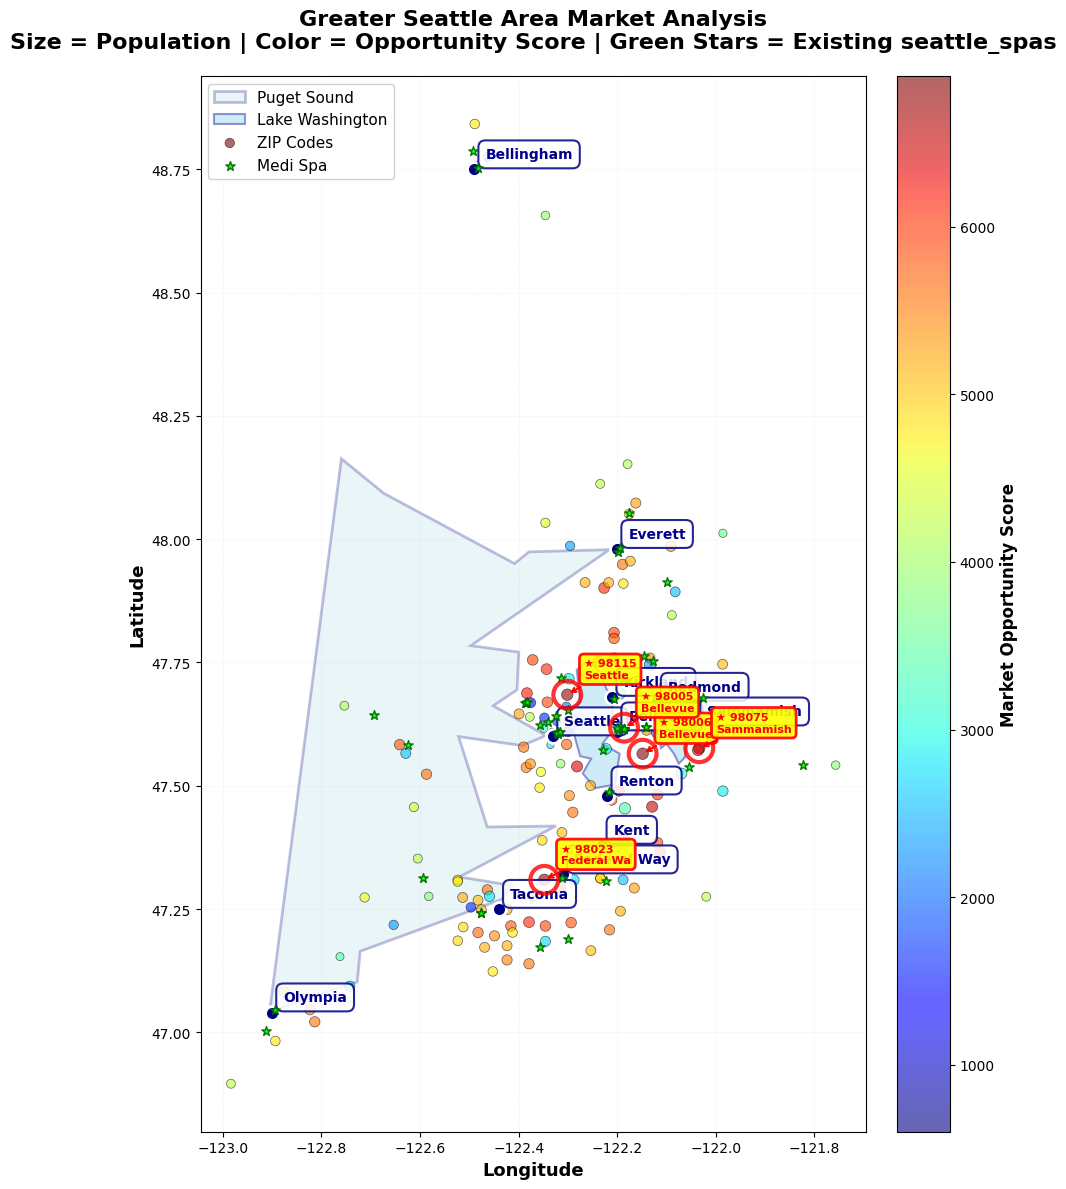

✅ Seattle area market analysis map created!


In [20]:
"""
Seattle Area Market Analysis with Geographic Overlay
"""

# Define Puget Sound geography
def create_puget_sound_overlay(ax):
    """Add Puget Sound and Lake Washington overlay"""
    
    # Puget Sound (simplified outline)
    puget_sound = [
    (-122.7594, 48.1633), # Admiralty Inlet (Entrance to the Sound)
    (-122.6738, 48.0934), # Marrowstone Point
    (-122.4083, 47.9506), # Possession Point (South Whidbey)
    (-122.3789, 47.9744), # Mukilteo Lighthouse
    (-122.2158, 47.9789), # Port of Everett
    (-122.4967, 47.7842), # Kingston Ferry Terminal
    (-122.3996, 47.7711), # Edmonds Marina
    (-122.4032, 47.6946), # Golden Gardens / Shilshole Bay
    (-122.4513, 47.6622), # Bainbridge Island (Eagle Harbor)
    (-122.3444, 47.6019), # Seattle Waterfront (Elliott Bay)
    (-122.3925, 47.5814), # Alki Point, West Seattle
    (-122.5217, 47.5997), # Bremerton Naval Shipyard
    (-122.4636, 47.4164), # Vashon Island (Point Robinson)
    (-122.3244, 47.4183), # Des Moines Marina
    (-122.5200, 47.3150), # Gig Harbor Entrance
    (-122.4131, 47.2978), # Point Defiance, Tacoma
    (-122.4344, 47.2694), # Commencement Bay / Port of Tacoma
    (-122.7214, 47.1642), # Anderson Island
    (-122.7272, 47.1022), # Nisqually River Delta
    (-122.9050, 47.0425)  # Budd Inlet, Olympia (Southern tip)
]
    
    # Lake Washington
    lake_washington = [
    (-122.2586, 47.7547), # Kenmore (Log Boom Park - North End)
    (-122.2355, 47.7300), # Saint Edward State Park (Kenmore/Kirkland)
    (-122.2222, 47.6975), # Juanita Beach Park (Kirkland)
    (-122.2091, 47.6750), # Heritage Park (Kirkland Waterfront)
    (-122.2100, 47.6450), # Carillon Point (Kirkland)
    (-122.2050, 47.6180), # Meydenbauer Bay Park (Bellevue)
    (-122.2300, 47.5850), # Mercer Island (East Channel Bridge)
    (-122.1950, 47.5650), # Newport Shores (Bellevue)
    (-122.2044, 47.5025), # Gene Coulon Memorial Beach Park (Renton)
    (-122.2450, 47.4950), # Renton Airport / Cedar River Mouth
    (-122.2700, 47.5250), # Skyway Shoreline (Southwest corner)
    (-122.2530, 47.5550), # Mercer Island (West Side / Luther Burbank Park)
    (-122.2750, 47.5600), # Seward Park (Seattle)
    (-122.2850, 47.5950), # Leschi Marina (Seattle)
    (-122.2880, 47.6150), # Madison Park (Seattle)
    (-122.2810, 47.6400), # Foster Island / Arboretum (Seattle)
    (-122.3020, 47.6480), # University of Washington Waterfront (Husky Stadium)
    (-122.2750, 47.6700), # Magnuson Park / Sand Point (Seattle)
    (-122.2800, 47.7150), # Matthews Beach Park (Seattle)
    (-122.2820, 47.7350)  # Lake City / Cedar Park (Northwest edge)
]

    
    # Lake Sammamish
    lake_sammamish = [
    (-122.1150, 47.6650), # Marymoor Park (Northern outlet/Sammamish River)
    (-122.1030, 47.6664), # East Lake Sammamish Trailhead (Redmond)
    (-122.0950, 47.6550), # Idylwood Beach Park (Northwest edge)
    (-122.0800, 47.6400), # Sammamish Landing Park
    (-122.0720, 47.6250), # Inglewood Hill area (East shore)
    (-122.0650, 47.6100), # Thompson Hill shoreline
    (-122.0620, 47.5950), # Pine Lake Creek mouth
    (-122.0600, 47.5800), # Ebright Creek area
    (-122.0627, 47.5590), # Lake Sammamish State Park Boat Launch
    (-122.0601, 47.5601), # Sunset Beach (Issaquah/South end)
    (-122.0650, 47.5550), # Tibbetts Beach (Issaquah/Southwest corner)
    (-122.0750, 47.5450), # Issaquah Creek inlet
    (-122.0850, 47.5650), # Greenwood Point (West shore)
    (-122.1000, 47.5850), # Vasa Park Resort
    (-122.1112, 47.5765), # USGS Monitoring Station (South Basin)
    (-122.1150, 47.6050), # Phantom Lake Creek drainage area
    (-122.1200, 47.6200), # Weowna Park shoreline
    (-122.1180, 47.6400), # West Lake Sammamish Parkway (Central West shore)
    (-122.1100, 47.6550), # Tam O'Shanter shoreline (Northwest)
    (-122.0894, 47.6166)  # Deep Central Basin (King County Station 0612)
]
    
    # Draw Puget Sound
    sound_polygon = Polygon(puget_sound, facecolor='lightblue', 
                           edgecolor='navy', alpha=0.25, linewidth=2, 
                           zorder=1, label='Puget Sound')
    ax.add_patch(sound_polygon)
    
    # Draw Lake Washington
    lake_wa_polygon = Polygon(lake_washington, facecolor='#87CEEB', 
                             edgecolor='darkblue', alpha=0.4, linewidth=1.5, 
                             zorder=2, label='Lake Washington')
    ax.add_patch(lake_wa_polygon)
    
    # Draw Lake Sammamish
    lake_sam_polygon = Polygon(lake_sammamish, facecolor='#87CEEB', 
                              edgecolor='darkblue', alpha=0.4, linewidth=1.5, 
                              zorder=2)
    ax.add_patch(lake_sam_polygon)
    
    return ax

# Create figure
fig, ax = plt.subplots(figsize=(16, 12))

# Add geography overlay
create_puget_sound_overlay(ax)

# Create scatter plot
scatter = ax.scatter(
    seattle_area["Longitude"], 
    seattle_area["Latitude"],
    alpha=0.6,
    s=seattle_area["Population (Women 35-65)"] / 100,
    c=seattle_area["Market Opportunity Score"],
    cmap=plt.get_cmap("jet"),
    edgecolors='black',
    linewidth=0.5,
    label="ZIP Codes",
    zorder=5
)

# Add medi spas
ax.scatter(seattle_spas["Longitude"], seattle_spas["Latitude"], 
          s=50, marker='*', c='#00FF00', 
          edgecolors='darkgreen', linewidth=1, 
          alpha=0.9, zorder=10, label='Medi Spa')

# Colorbar
cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label('Market Opportunity Score', fontsize=12, fontweight='bold')

# Major cities
major_cities = [
    ('Seattle', -122.33, 47.60),
    ('Bellevue', -122.20, 47.61),
    ('Tacoma', -122.44, 47.25),
    ('Everett', -122.20, 47.98),
    ('Kirkland', -122.21, 47.68),
    ('Redmond', -122.12, 47.67),
    ('Renton', -122.22, 47.48),
    ('Kent', -122.23, 47.38),
    ('Federal Way', -122.31, 47.32),
    ('Olympia', -122.90, 47.04),
    ('Bellingham', -122.49, 48.75),
    ('Sammamish', -122.04, 47.62),
]

for city, lon, lat in major_cities:
    ax.plot(lon, lat, 'o', color='navy', markersize=10, zorder=8, 
            markeredgecolor='white', markeredgewidth=2)
    ax.annotate(city, (lon, lat), 
                xytext=(8, 8), textcoords='offset points',
                fontsize=10, fontweight='bold', color='darkblue',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='white', 
                         edgecolor='navy', alpha=0.85, linewidth=1.5),
                zorder=9)

# Highlight top 5 opportunities
top_5 = seattle_area.head(5)
for idx, row in top_5.iterrows():
    ax.scatter(row['Longitude'], row['Latitude'], 
              s=400, facecolors='none', edgecolors='red', 
              linewidth=3, zorder=10, alpha=0.8)
    ax.annotate(f"★ {row['ZIP Code']}\n{row['City'][:10]}", 
               (row['Longitude'], row['Latitude']),
               xytext=(12, 12), textcoords='offset points',
               fontsize=8, fontweight='bold', color='red',
               bbox=dict(boxstyle='round,pad=0.4', facecolor='yellow', 
                        edgecolor='red', alpha=0.9, linewidth=2),
               arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
               zorder=11)

# Formatting
ax.set_xlabel('Longitude', fontsize=13, fontweight='bold')
ax.set_ylabel('Latitude', fontsize=13, fontweight='bold')
ax.set_title('Greater Seattle Area Market Analysis\nSize = Population | Color = Opportunity Score | Green Stars = Existing seattle_spas', 
            fontsize=16, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)
ax.legend(loc='upper left', fontsize=11, framealpha=0.9)
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig('market_analysis_maps/seattle_area_market_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Seattle area market analysis map created!")

In [22]:
seattle_spas.head(100)

,Medi Spa Name,Address,City,ZIP Code,Latitude,Longitude,Services,Price Range
0,Well Medical Arts,2366 Eastlake Ave E,Seattle,98102,47.6421,-122.3243,"Botox, Fillers, Laser, Facials",$$$$
1,Allure Esthetic,1101 Madison St Suite 1280,Seattle,98104,47.6095,-122.3201,"Medical Spa, Injectables, Body Contouring",$$$$
2,Seattle Plastic Surgery,600 Broadway Suite 320,Seattle,98122,47.6043,-122.3201,"Botox, Fillers, CoolSculpting",$$$$
3,The Langdon Center,910 Broadway,Seattle,98122,47.6064,-122.3211,Full Service Medical Spa,$$$$
4,Skin Spirit,2208 NW Market St,Seattle,98107,47.6686,-122.3856,"Botox, Fillers, Laser Facials",$$$$
5,Modbar Skin,2100 NW Market St Suite 212,Seattle,98107,47.6684,-122.3867,"Medical-grade Facials, Laser",$$$
6,Egrari Skin,1200 Westlake Ave N Suite 900,Seattle,98109,47.6283,-122.3394,"Advanced Skincare, Injectables",$$$$
7,Queen Anne Laser & Skin Care,550 1st Ave N,Seattle,98109,47.6239,-122.3561,"Laser Hair Removal, Skin Rejuvenation",$$$
8,Rejuvenation MD,1229 Madison St Suite 1240,Seattle,98104,47.6097,-122.3167,"Anti-aging, Hormone Therapy, Medical Spa",$$$$
9,Alegria Medical Spa,4540 Union Bay Pl NE,Seattle,98105,47.6534,-122.2989,"Botox, Fillers, Laser",$$$
